In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from scipy.interpolate import RectBivariateSpline

torch.set_default_dtype(torch.float64)

In [2]:
%run func_defs.ipynb

In [3]:
def pt_2d_interpolation(z, t, U, **kwargs):
    """
    PyTorch-compatible 2D interpolator using RectBivariateSpline.
    z  : (nz+1,)          spatial grid
    t  : (n_out+1,)       time grid
    U  : (nz+1, n_out+1)  U[i,j] = solution at (z[i], t[j])
    Returns interp(z_q, t_q[, dx=1 or dy=1])
    """
    defaults = {'kx': 3, 'ky': 3, 's': 0}
    defaults.update(kwargs)
    rbs = RectBivariateSpline(
        z.cpu().numpy(), t.cpu().numpy(), U.cpu().numpy(), **defaults
    )
    def interp(z_q, t_q, **ev_kwargs):
        z_q, t_q = torch.broadcast_tensors(
            torch.as_tensor(z_q, dtype=U.dtype),
            torch.as_tensor(t_q, dtype=U.dtype),
        )
        vals = rbs.ev(z_q.cpu().numpy(), t_q.cpu().numpy(), **ev_kwargs)
        return torch.from_numpy(vals).to(device=U.device, dtype=U.dtype)
    interp._rbs = rbs
    return interp

In [4]:
def pt_2d_interp_piecewise(z, t, U, z_dis, **kwargs):
    """
    Separate cubic spline each side of z_dis.
    Falls back to full cubic if either side has < kx+1 points.
    """
    defaults = {'kx': 3, 'ky': 3, 's': 0}
    defaults.update(kwargs)
    min_pts = defaults['kx'] + 1
    m = torch.searchsorted(z, torch.tensor(z_dis, device=z.device)).item()
    n_left, n_right = m + 1, len(z) - m
    if n_left < min_pts or n_right < min_pts:
        print(f'[interp_pw] warning: {n_left} left / {n_right} right points '
              f'(need ≥{min_pts}). Falling back to full cubic.')
        return pt_2d_interpolation(z, t, U, **defaults)
    interp_L = pt_2d_interpolation(z[:m+1], t, U[:m+1, :], **defaults)
    interp_R = pt_2d_interpolation(z[m:],   t, U[m:,   :], **defaults)
    def interp(z_q, t_q, **ev_kwargs):
        z_q = torch.as_tensor(z_q, dtype=z.dtype, device=z.device)
        t_q = torch.as_tensor(t_q, dtype=t.dtype, device=t.device)
        z_q, t_q = torch.broadcast_tensors(z_q, t_q)
        out  = torch.zeros_like(z_q)
        mask = z_q <= z_dis
        if mask.any():  out[mask]  = interp_L(z_q[mask],  t_q[mask],  **ev_kwargs)
        if (~mask).any(): out[~mask] = interp_R(z_q[~mask], t_q[~mask], **ev_kwargs)
        return out
    return interp

In [5]:
def set_BCs(T):
    T[0]  = T[2]
    T[-1] = T[-2] ** 2 / max(T[-3].item(), 1e-40)

In [6]:
def solve_two_layer_FD(k1, k2, z_dis, Pda, Lz, nz, tf, device, M=320, verbose=True):
    """
    Solve the two-layer heat equation from t=0 to t=tf.
    n_true = smallest integer s.t.  M * delta > tf,  delta = n_true * dt.
    Solution saved every n_true fine steps — no resampling.
    Returns: z (nz+1,), t_out (n_out+1,), U_coarse (nz+1, n_out+1), n_true, delta
    """
    dz = Lz / nz
    z  = torch.arange(-1, nz + 2, device=device) * dz
    m  = torch.searchsorted(z, z_dis - 0.5 * dz, right=True).item()
    if verbose:
        print(f'Interface alignment error: {z[m].item() - z_dis:.2e}')
    k_iL = 8 * k1 * k2 / (k1 + 7 * k2)
    k_iR = 8 * k1 * k2 / (7 * k1 + k2)
    kh   = torch.where(
        z[:-1] < z_dis - 0.5 * dz,
        torch.tensor(k1, device=device),
        torch.tensor(k2, device=device),
    )
    kh[m - 1] = k_iL
    kh[m]     = k_iR
    dt_stab = 0.5 * (dz ** 2) / max(k1, k2)
    n_fine  = int(np.ceil(tf / dt_stab))
    dt      = tf / n_fine
    n_true  = int(n_fine // M) + 1
    delta   = n_true * dt
    if verbose:
        print(f'dt_stab={dt_stab:.4e}  n_fine={n_fine}  dt={dt:.4e}')
        print(f'n_true={n_true}  delta={delta:.6f}  '
              f'{M}*delta={M*delta:.4f} > tf={tf}: {M*delta > tf}')
        print(f'n_out={n_fine // n_true}  (excluding t=0)')
    source    = Pda * torch.exp(-z[1:-1])
    source[0] = Pda * torch.exp(-z[2] / 4)
    T = torch.zeros(nz + 3, device=device)
    # t=0 saved as first entry
    buf_U = [T[1:-1].cpu().clone()]
    buf_t = [0.0]
    for step in range(n_fine):
        set_BCs(T)
        Jh      = -kh * (T[1:] - T[:-1]) / dz
        T[1:-1] = T[1:-1] + dt / dz * (Jh[:-1] - Jh[1:]) + dt * source
        if (step + 1) % n_true == 0:
            buf_U.append(T[1:-1].cpu().clone())
            buf_t.append((step + 1) * dt)
    set_BCs(T)
    T[m] = T[m] + (2 * T[m] - T[m - 1] - T[m + 1]) / 6
    U_coarse = torch.stack(buf_U, dim=1).to(device)         # (nz+1, n_out+1)
    t_out    = torch.tensor(np.array(buf_t), device=device)  # (n_out+1,)
    if verbose:
        print(f't[0]={t_out[0].item():.4f}  t[-1]={t_out[-1].item():.4f}  n_t={len(t_out)}')
    return z[1:-1], t_out, U_coarse, n_true, delta

In [7]:
def smooth_U(U, z, z_dis, k1, k2):
    """Rescale z < z_dis to enforce the flux interface condition."""
    alpha    = k1 / k2
    m        = torch.searchsorted(z, torch.tensor(z_dis, device=z.device)).item()
    U_smooth = U.clone()
    U_smooth[:m, :] = U[m, :] + alpha * (U[:m, :] - U[m, :])
    return U_smooth

In [8]:
_VALID_KEYS = frozenset({
    'U', 'U_raw', 'z', 't', 'stau', 'W', 'kratio', 'z_dis',
    'dataset', 'interp', 'interp_lin', 'interp_pw',
})

class Solver:
    """
    Two-layer FD solver — v10.
    sol['t'][0]=0, sol['U'][:,0]=0 (initial condition).
    stau and W built from t>0 only (t=0 singular in transform and W=U/t).
    """
    def __init__(self, k1, k2, z_dis, Pda, Lz, nz, tf,
                 device='cpu', M=320, verbose=True):
        self._p = dict(k1=k1, k2=k2, z_dis=z_dis, Pda=Pda,
                       Lz=Lz, nz=nz, tf=tf, M=M, device=device)
        self._verbose = verbose
        self._cache   = {}
        self._run()

    def _run(self):
        p = self._p
        z, t_out, U_raw, n_true, delta = solve_two_layer_FD(
            p['k1'], p['k2'], p['z_dis'], p['Pda'],
            p['Lz'], p['nz'], p['tf'],
            p['device'], M=p['M'], verbose=self._verbose,
        )
        self._n_true = n_true
        self._delta  = delta
        U_smooth   = smooth_U(U_raw, z, p['z_dis'], p['k1'], p['k2'])
        interp_cub = pt_2d_interpolation(z, t_out, U_smooth, kx=3, ky=3, s=0)
        interp_lin = pt_2d_interpolation(z, t_out, U_smooth, kx=1, ky=1, s=0)
        interp_pw  = pt_2d_interp_piecewise(
            z, t_out, U_smooth, p['z_dis'], kx=3, ky=3, s=0
        )
        # stau and W: skip t=0
        t_pos  = t_out[1:]
        U_pos  = U_smooth[:, 1:]
        zt     = torch.cartesian_prod(z, t_pos)
        ss, ttau = z_t_to_s_tau(zt[:, 0], zt[:, 1])
        stau   = torch.column_stack((ss, ttau))
        W      = (U_pos / t_pos).reshape(-1, 1)
        n_pts  = len(stau)
        kratio = torch.full((n_pts,), p['k1'] / p['k2'], device=p['device'])
        z_disv = torch.full((n_pts,), p['z_dis'],        device=p['device'])
        self._cache = {
            'U':          U_smooth,
            'U_raw':      U_raw,
            'z':          z,
            't':          t_out,
            'stau':       stau,
            'W':          W,
            'kratio':     kratio,
            'z_dis':      z_disv,
            'interp':     interp_cub,
            'interp_lin': interp_lin,
            'interp_pw':  interp_pw,
        }

    def __getitem__(self, key):
        if key not in _VALID_KEYS:
            raise KeyError(f'Unknown key {key!r}. Valid: {sorted(_VALID_KEYS)}')
        if key == 'dataset': return self._build_dataset()
        return self._cache[key]

    def _build_dataset(self):
        c = self._cache
        return {'t': c['stau'][:, 1], 'z': c['stau'][:, 0],
                'kratio': c['kratio'], 'zdis': c['z_dis'],
                'stau': c['stau'], 'W': c['W']}

    def keys(self): return sorted(_VALID_KEYS)

    def save(self, path):
        torch.save(self._build_dataset(), path)
        if self._verbose: print(f'Dataset saved to {path}')

    def __repr__(self):
        p = self._p
        return (f"Solver(k1={p['k1']}, k2={p['k2']}, z_dis={p['z_dis']}, "
                f"Pda={p['Pda']}, Lz={p['Lz']}, nz={p['nz']}, tf={p['tf']}, "
                f"M={p['M']}, n_true={self._n_true}, delta={self._delta:.6f}, "
                f"device={p['device']!r})")

## Run

In [9]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

sol = Solver(
    k1=1.0, k2=2.0, z_dis=1.0, Pda=1.0,
    Lz=16.0, nz=640, tf=20.0,
    device=device, M=320,
)
print(sol)
print('Keys:', sol.keys())

Interface alignment error: 0.00e+00
dt_stab=1.5625e-04  n_fine=128000  dt=1.5625e-04
n_true=401  delta=0.062656  320*delta=20.0500 > tf=20.0: True
n_out=319  (excluding t=0)
t[0]=0.0000  t[-1]=19.9873  n_t=320
Solver(k1=1.0, k2=2.0, z_dis=1.0, Pda=1.0, Lz=16.0, nz=640, tf=20.0, M=320, n_true=401, delta=0.062656, device='cuda')
Keys: ['U', 'U_raw', 'W', 'dataset', 'interp', 'interp_lin', 'interp_pw', 'kratio', 'stau', 't', 'z', 'z_dis']


/tmp/ipykernel_317/2287032977.py:22: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout(); plt.show()


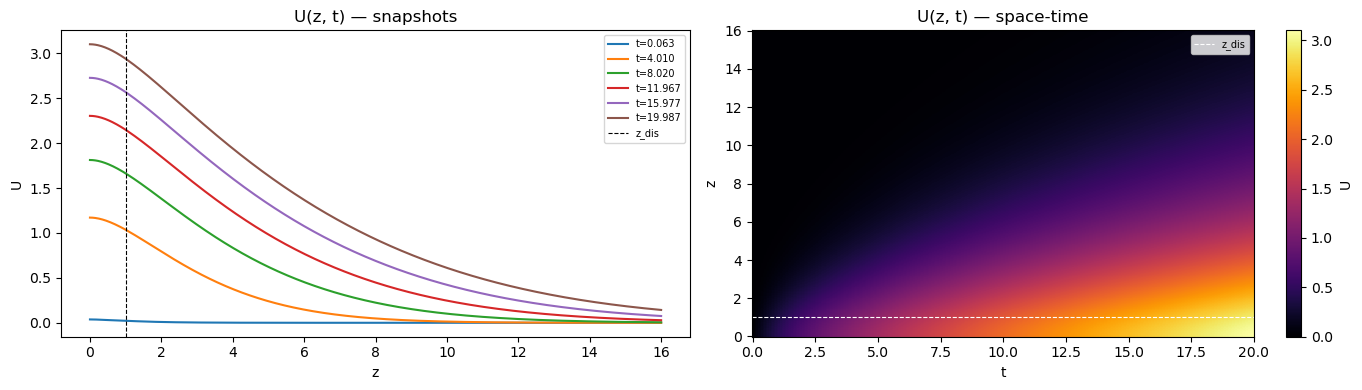

In [10]:
U     = sol['U']
z_plt = sol['z'].cpu()
t_plt = sol['t'].cpu()
idx   = torch.linspace(1, len(t_plt) - 1, 6).long()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
for i in idx:
    ax.plot(z_plt, U[:, i].cpu(), label=f't={t_plt[i]:.3f}')
ax.axvline(sol._p['z_dis'], color='k', linestyle='--', lw=0.8, label='z_dis')
ax.set_xlabel('z'); ax.set_ylabel('U')
ax.set_title('U(z, t) — snapshots'); ax.legend(fontsize=7)

ax = axes[1]
im = ax.pcolormesh(t_plt.numpy(), z_plt.numpy(), U.cpu().numpy(),
                   shading='auto', cmap='inferno')
ax.axhline(sol._p['z_dis'], color='w', linestyle='--', lw=0.8, label='z_dis')
ax.set_xlabel('t'); ax.set_ylabel('z')
ax.set_title('U(z, t) — space-time')
plt.colorbar(im, ax=ax, label='U'); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()